Data Preprocessing

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
#from tensorflow.keras.utils import to_categorical

In [63]:
additional_test = pd.read_csv('test/Features/additional_features.csv')
color_test = pd.read_csv('test/Features/color_histogram.csv')
hog_test = pd.read_csv('test/Features/hog_pca.csv')
testing = pd.read_csv('test/test_metadata.csv')

additional_train = pd.read_csv('train/Features/additional_features.csv')
color_train = pd.read_csv('train/Features/color_histogram.csv')
hog_train = pd.read_csv('train/Features/hog_pca.csv')
training = pd.read_csv('train/train_metadata.csv')


# PREPROCESSING THE DATA
# No need for handling missing values as the training set seems to be complete
#print(combined.isna().sum())

# Standardising additional_features 
additional_features_columns = ['edge_density', 'mean_b', 'mean_g', 'mean_r']
scaler = StandardScaler()
additional_train[additional_features_columns] = scaler.fit_transform(additional_train[additional_features_columns])

# Standardising color histograms
color_columns = [col for col in color_train.columns if col.startswith("ch_")]
color_train[color_columns] = scaler.fit_transform(color_train[color_columns])


# Once preprocessed, we can now merge the features together for the training metadata set
combined = pd.merge(training, additional_train, on='image_path')
combined = pd.merge(combined, color_train, on='image_path')
combined = pd.merge(combined, hog_train, on='image_path')
combined = combined[[col for col in combined.columns if col != 'ClassId'] + ['ClassId']]


In [62]:
# NEURAL NETWORK
X_train = np.array(combined.drop(columns=['id', 'image_path', 'ClassId']))
Y_train = np.array(combined['ClassId'])

X = X_train.T
m, n = X_train.shape

indices = np.arange(X_train.shape[0])
np.random.shuffle(indices)

X_train = X_train[indices]
Y_train = Y_train[indices]


Epoch 0, Loss: 4.3528, Accuracy: 2.7332
Epoch 100, Loss: 1.4798, Accuracy: 61.4249
Epoch 200, Loss: 1.0650, Accuracy: 73.3236
Epoch 300, Loss: 0.8466, Accuracy: 79.9563
Epoch 400, Loss: 0.7042, Accuracy: 84.2748
Epoch 500, Loss: 0.6023, Accuracy: 87.2449
Epoch 600, Loss: 0.5251, Accuracy: 89.4133
Epoch 700, Loss: 0.4646, Accuracy: 90.7981
Epoch 800, Loss: 0.4158, Accuracy: 92.0736
Epoch 900, Loss: 0.3754, Accuracy: 93.0029


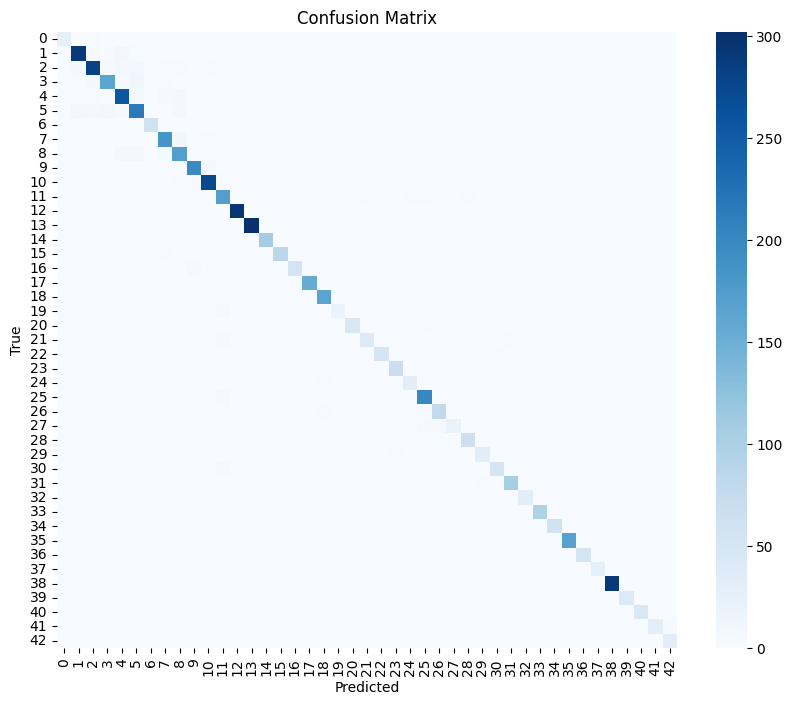

              precision    recall  f1-score   support

           0       1.00      0.86      0.93        29
           1       0.93      0.94      0.93       311
           2       0.92      0.89      0.91       315
           3       0.90      0.84      0.87       197
           4       0.88      0.92      0.90       277
           5       0.84      0.83      0.84       260
           6       0.97      1.00      0.98        59
           7       0.91      0.92      0.91       202
           8       0.84      0.88      0.86       197
           9       0.96      0.95      0.96       206
          10       0.95      0.98      0.96       281
          11       0.86      0.94      0.90       185
          12       1.00      1.00      1.00       294
          13       1.00      1.00      1.00       302
          14       1.00      0.99      1.00       109
          15       1.00      0.97      0.98        88
          16       0.96      0.92      0.94        59
          17       0.99    

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report

numInputs = X.shape[0]
numHidden = 256
numOutput = 43

# Necessary functions for the neural network
def init_params():
    W1 = np.random.randn(numHidden, numInputs) * np.sqrt(2. / numInputs)
    b1 = np.zeros((numHidden, 1))
    W2 = np.random.randn(numOutput, numHidden) * np.sqrt(2. / numHidden)
    b2 = np.zeros((numOutput, 1))
    return W1, b1, W2, b2

def forward_propagation(X, W1, b1, W2, b2):
    Z1 = np.dot(W1, X) + b1  
    A1 = np.maximum(0, Z1) 
    Z2 = np.dot(W2, A1) + b2
    exp_scores = np.exp(Z2 - np.max(Z2, axis=0, keepdims=True))
    A2 = exp_scores / np.sum(exp_scores, axis=0, keepdims=True)
    return A1, A2

def backward_propagation(X, Y, A1, A2, W1, W2):
    m = X.shape[1]
    dZ2 = A2 - Y 
    dW2 = (1 / m) * np.dot(dZ2, A1.T)
    db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)
    
    dZ1 = np.dot(W2.T, dZ2) * (A1 > 0)
    dW1 = (1 / m) * np.dot(dZ1, X.T)
    db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

def one_hot_encode(Y, num_classes):
    m = Y.shape[0]
    Y_encoded = np.zeros((num_classes, m))
    Y_encoded[Y, np.arange(m)] = 1
    return Y_encoded

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    return W1, b1, W2, b2

def get_accuracy(A2, Y):
    predictions = np.argmax(A2, axis=0)
    accuracy = np.mean(predictions == Y)
    return accuracy*100

def predict(A2):
    return np.argmax(A2, axis=0)

def gradient_descent(X, Y, W1, b1, W2, b2, learning_rate=0.01, epochs=1000):
    Y_encoded = one_hot_encode(Y, numOutput)
    for epoch in range(epochs):
        A1, A2 = forward_propagation(X, W1, b1, W2, b2)
        dW1, db1, dW2, db2 = backward_propagation(X, Y_encoded, A1, A2, W1, W2)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)
        
        if epoch % 100 == 0:
            log_probs = -np.log(A2[Y, np.arange(Y.shape[0])])
            loss = np.mean(log_probs)
            print(f'Epoch {epoch}, Loss: {loss:.4f}, Accuracy: {get_accuracy(A2, Y):.4f}')
    
    return W1, b1, W2, b2

X = X_train.T 
W1, b1, W2, b2 = gradient_descent(X, Y_train, *init_params(), learning_rate=0.1, epochs=1000)


# Confusion Matrix
A1, A2 = forward_propagation(X, W1, b1, W2, b2)
Y_pred = predict(A2)
conf_matrix = confusion_matrix(Y_train, Y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=False, cmap='Blues', fmt='g')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(Y_train, Y_pred))
# numhidden: 512 = 93.0029
# numhidden: 368 = 91.8732
# numhidden: 300 = 90.1786
# numhidden: 256 = 88.9759


